In [1]:
import pandas
from langchain_ollama.chat_models import ChatOllama
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

from langgraph.graph import StateGraph, START, MessagesState, END

from typing import Annotated, Literal, TypedDict
from langgraph.types import Command

from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [2]:
OLLAMA_HOST: str = '192.168.107.42'
OLLAMA_PORT: str = '11434'
OLLAMA_MODEL: str = 'llama3.1:latest'
OLLAMA_TEMPERATURE: int = 0
OLLAMA_TIMEOUT: int = 3600
OLLAMA_NUM_THREADS: int = 8

OLLAMA_URL= f"http://{OLLAMA_HOST}:{OLLAMA_PORT}"

In [3]:
llm = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)

# **Chat-Bot**

In [4]:
from langgraph.prebuilt import create_react_agent
def search_wikipedia(topic) -> str:
    """
    Herramienta que sirve para buscar en la wikipedia 
    
    Args:
        topic tema buscar en la wikipedia
    return: 
        Información encontrada en la wikipedia
    """
    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wikipedia.run(topic)


system_prompt="Eres un historiador y tienes que utilizar la funcion search_wikipedia para encontrar información relacionada con las preguntas del usuario"
    
wiki_agent = create_react_agent(
      llm,
      tools=[search_wikipedia], 
      state_modifier=system_prompt
    )

def wiki_node(state: MessagesState) -> Command[Literal["__end__"]]:
    result = wiki_agent.invoke(state)
    return Command(
        update={
            "messages": [
                AIMessage(content=result["messages"][-1].content, name="historiador")
            ]
        },
        goto="__end__",
    )    

In [5]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [6]:
llm = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

In [7]:
llm.invoke("Cuando ha muerto John Sykes")

AIMessage(content='No tengo información sobre la fecha de fallecimiento de John Sykes.', additional_kwargs={}, response_metadata={'model': 'llama3.1:latest', 'created_at': '2025-01-22T09:02:23.593886779Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1753074254, 'load_duration': 16943322, 'prompt_eval_count': 18, 'prompt_eval_duration': 642000000, 'eval_count': 16, 'eval_duration': 1093000000, 'message': Message(role='assistant', content='', images=None, tool_calls=None)}, id='run-18241c8e-1dd2-42dd-b91a-439a0260a64a-0', usage_metadata={'input_tokens': 18, 'output_tokens': 16, 'total_tokens': 34})

In [8]:
#historiador
builder = StateGraph(MessagesState)
builder.add_edge(START, "historiador")
builder.add_node("historiador", wiki_node)

grph = builder.compile()

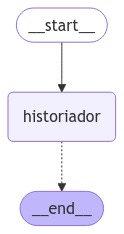

In [9]:
from IPython.display import Image, display

try:
    display(Image(grph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [26]:
value = grph.invoke({"messages": [HumanMessage(content="Cuando ha muerto John Sykes")]}, {"recursion_limit": 100},debug=True)


print("Assistant:", value["messages"][-1].content)

[-1:checkpoint] State at the end of step -1:
{'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [HumanMessage(content='Cuando ha muerto John Sykes', additional_kwargs={}, response_metadata={})]}
[0:writes] Finished step 0 with writes to 1 channel:
- messages -> [HumanMessage(content='Cuando ha muerto John Sykes', additional_kwargs={}, response_metadata={})]
[0:checkpoint] State at the end of step 0:
{'messages': [HumanMessage(content='Cuando ha muerto John Sykes', additional_kwargs={}, response_metadata={}, id='42dc1ead-bd06-4a23-b16e-03c39846f7e6')]}
[1:tasks] Starting 1 task for step 1:
- historiador -> {'messages': [HumanMessage(content='Cuando ha muerto John Sykes', additional_kwargs={}, response_metadata={}, id='42dc1ead-bd06-4a23-b16e-03c39846f7e6')]}


/root/alba_dev/bRAG-langchain/.venvlang/lib/python3.11/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /root/alba_dev/bRAG-langchain/.venvlang/lib/python3.11/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


[1:writes] Finished step 1 with writes to 1 channel:
- messages -> [AIMessage(content='Según la información disponible en Wikipedia, John Sykes murió en enero de 2025.', additional_kwargs={}, response_metadata={}, name='historiador')]
[1:checkpoint] State at the end of step 1:
{'messages': [HumanMessage(content='Cuando ha muerto John Sykes', additional_kwargs={}, response_metadata={}, id='42dc1ead-bd06-4a23-b16e-03c39846f7e6'),
              AIMessage(content='Según la información disponible en Wikipedia, John Sykes murió en enero de 2025.', additional_kwargs={}, response_metadata={}, name='historiador', id='5471f2ad-b29e-4d52-a7b6-5331e0f153b4')]}
Assistant: Según la información disponible en Wikipedia, John Sykes murió en enero de 2025.


In [10]:
search_wikipedia("John Sykes")

/root/alba_dev/bRAG-langchain/.venvlang/lib/python3.11/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /root/alba_dev/bRAG-langchain/.venvlang/lib/python3.11/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


'Page: John Sykes\nSummary: John James Sykes (29 July 1959 – January 2025) was an English guitarist, best known as a member of Whitesnake, Thin Lizzy and Tygers of Pan Tang. He also fronted the hard rock group Blue Murder and released several solo albums.\nFollowing a stint in the heavy metal band Tygers of Pan Tang in the early 1980s, Sykes joined Irish hard rock group Thin Lizzy for their 1983 album Thunder and Lightning. He then joined Whitesnake with whom he recorded the multi-platinum-selling self-titled 1987 album. However, Sykes was fired from the band before the record\'s release under acrimonious circumstances, which led to him forming his own group Blue Murder. After two albums and a live record, he embarked on a solo career. For the remainder of the 1990s and early 2000s, Sykes split his time between his solo career and a reformed Thin Lizzy, which he fronted until 2009, when he left to focus on his solo career.\nInfluenced by the likes of Jimmy Page, Ritchie Blackmore and G

In [6]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("historiador", END)
graph = graph_builder.compile()

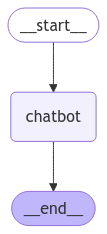

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break


        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "q"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: It seems like you were about to ask a question, but it got cut off. What's on your mind? Do you have a query or topic you'd like to discuss? I'm here to help with any questions or topics you'd like to explore!
User: q
Assistant: It looks like you might have entered a single character "q" by mistake. If you meant to ask something, please feel free to type it out and I'll do my best to help!


## **Tools**

In [13]:
from langchain_community.tools import BraveSearch
tool = BraveSearch.from_api_key( search_kwargs={"count": 3})
tool.run("obama middle name")




TypeError: BraveSearch.from_api_key() missing 1 required positional argument: 'api_key'

# **Multi-agent supervisor**